# Parsing Tasks Aggregated Analysis

## Executive Summary

**Objective:** Aggregate and compare parsing performance across all datasets to answer 3 key questions:

### 🎯 Key Questions:
1. **Which is the best phase for each dataset?**
2. **Which is the best model per phase for each dataset?**
3. **What's the best combination (phase + model) for each dataset?**

**Datasets Included:**
- ✅ **IAM_mini** (500 samples, 3 phases) - Handwriting Recognition
- ✅ **ICDAR_mini** (491 samples, 3 phases) - Multilingual OCR
- ✅ **VOC2007** (238 samples, 4 phases) - Chinese Medical Text
- ✅ **RX-PAD** (200 samples, 3 phases) - French Medical Forms

**Evaluation Metrics:**
- 🎯 **PRIMARY: Cosine Similarity** (semantic similarity, higher is better)
- **SECONDARY:** CER (Character Error Rate, lower is better), WER (Word Error Rate, lower is better)

**Phases:**
- **P-A (Pa):** OCR Baseline
- **P-B (Pb):** VLM with generic prompts
- **P-C (Pc):** VLM with task-aware prompts
- **P-D (Pd):** VLM with detailed context (VOC2007 only)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import sys
from pathlib import Path
from typing import List, Dict, Optional
import warnings
warnings.filterwarnings('ignore')

from tqdm.notebook import tqdm

# Setup paths
NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent.parent.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Import metrics
from ocr_vs_vlm.metrics.evaluation_metrics import calculate_cer, calculate_wer
from ocr_vs_vlm.metrics.embedding_cache import EmbeddingCacheManager, save_embeddings_for_phase

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')

# Paths
RESULTS_BASE = REPO_ROOT / 'ocr_vs_vlm' / 'results'
EMBEDDINGS_DIR = RESULTS_BASE / '3_embeddings'

print("✅ Libraries loaded successfully!")
print(f"📂 Results base: {RESULTS_BASE}")
print(f"📂 Embeddings: {EMBEDDINGS_DIR}")


✅ Libraries loaded successfully!
📂 Results base: /Users/kenzabenkirane/Documents/GitHub/research-playground/ocr_vs_vlm/results
📂 Embeddings: /Users/kenzabenkirane/Documents/GitHub/research-playground/ocr_vs_vlm/results/3_embeddings


In [ ]:
# Dataset configuration
PARSING_DATASETS = {
    'IAM_mini': {
        'path': RESULTS_BASE / '2_clean' / 'IAM_mini',
        'task': 'handwriting',
        'phases': ['Pa', 'Pb', 'Pc'],
        'chunk_size': None
    },
    'ICDAR_mini': {
        'path': RESULTS_BASE / '2_clean' / 'ICDAR_mini',
        'task': 'multilingual',
        'phases': ['Pa', 'Pb', 'Pc'],
        'chunk_size': 150
    },
    'VOC2007': {
        'path': RESULTS_BASE / '2_clean' / 'VOC2007',
        'task': 'medical_chinese',
        'phases': ['Pa', 'Pb', 'Pc', 'Pd'],
        'chunk_size': 200
    },
    'RX-PAD': {
        'path': RESULTS_BASE / '2_clean' / 'RX-PAD',
        'task': 'medical_french',
        'phases': ['Pa', 'Pb', 'Pc'],
        'chunk_size': 200
    }
}

print("📁 Dataset Configuration:")
for name, config in PARSING_DATASETS.items():
    print(f"  - {name}: {len(config['phases'])} phases, task={config['task']}")


📁 Dataset Configuration:
  - IAM_mini: 3 phases, task=handwriting
  - ICDAR_mini: 3 phases, task=multilingual
  - VOC2007: 4 phases, task=medical_chinese
  - RX-PAD: 3 phases, task=medical_french


In [ ]:
def is_valid_row(row, pred_col: str, err_col: Optional[str] = None) -> bool:
    """Check if prediction is valid (non-empty, no error)"""
    pred_value = row[pred_col]
    if pd.isna(pred_value) or str(pred_value).strip() == "":
        return False
    if err_col and err_col in row.index:
        if pd.notna(row[err_col]) and str(row[err_col]).strip() != "":
            return False
    return True

def calculate_metrics(gt: str, pred: str, phase: str, sample_id: str, 
                     model: str, emb_manager: EmbeddingCacheManager) -> Dict:
    """Calculate CER, WER, and Cosine Similarity
    
    Note: Uses sample_id as the ground truth cache key to ensure unique embeddings
    per sample, preventing cache collisions when different samples have identical text.
    """
    if pd.isna(pred) or str(pred).strip() == "":
        return {'cer': 1.0, 'wer': 1.0, 'cosine_similarity': 0.0}
    
    gt_str = str(gt)
    pred_str = str(pred)
    
    return {
        'cer': float(calculate_cer(gt_str, pred_str)),
        'wer': float(calculate_wer(gt_str, pred_str)),
        'cosine_similarity': float(emb_manager.compute_cosine_similarity(
            phase=phase, ground_truth=gt_str, prediction=pred_str,
            sample_id=sample_id, model=model,
            gt_sample_id=sample_id  # Use sample_id as cache key for ground truth
        ))
    }

print("✅ Helper functions defined")

✅ Helper functions defined


In [ ]:
# Load all datasets
all_data = {}
embedding_managers = {}

for dataset_name, config in PARSING_DATASETS.items():
    print(f"\nLoading {dataset_name}...")
    
    # Initialize embedding manager
    emb_manager = EmbeddingCacheManager(dataset_name, EMBEDDINGS_DIR)
    embedding_managers[dataset_name] = emb_manager
    
    dataset_dfs = {}
    for phase in config['phases']:
        file_path = config['path'] / f"{phase}.csv"
        if file_path.exists():
            df = pd.read_csv(file_path)
            dataset_dfs[phase] = df
            print(f"  ✅ {phase}: {len(df)} samples")
    
    all_data[dataset_name] = {
        'config': config,
        'phase_dfs': dataset_dfs
    }

print(f"\n✅ Loaded {len(all_data)} datasets")



Loading IAM_mini...
  ✅ Pa: 500 samples
  ✅ Pb: 500 samples
  ✅ Pc: 500 samples

Loading ICDAR_mini...
  ✅ Pa: 491 samples
  ✅ Pb: 491 samples
  ✅ Pc: 491 samples

Loading VOC2007...
  ✅ Pa: 238 samples
  ✅ Pb: 238 samples
  ✅ Pc: 238 samples
  ✅ Pd: 238 samples

Loading RX-PAD...
  ✅ Pa: 200 samples
  ✅ Pb: 200 samples
  ✅ Pc: 200 samples

✅ Loaded 4 datasets


In [ ]:
# Calculate metrics for all datasets
all_metrics = []

for dataset_name, data in all_data.items():
    print(f"\nCalculating metrics for {dataset_name}...")
    config = data['config']
    emb_manager = embedding_managers[dataset_name]
    
    for phase, df in data['phase_dfs'].items():
        pred_cols = [col for col in df.columns if col.startswith('prediction_')]
        
        for pred_col in pred_cols:
            model = pred_col.replace('prediction_', '')
            err_col = f'error_{model}'
            
            # Get valid rows
            valid_rows = [r for _, r in df.iterrows() if is_valid_row(r, pred_col, err_col)]
            
            if not valid_rows:
                continue
            
            # Calculate metrics
            metrics_list = []
            for row in tqdm(valid_rows, desc=f"  {phase}/{model}", leave=False):
                m = calculate_metrics(
                    row['ground_truth'], row[pred_col], phase,
                    row['sample_id'], model, emb_manager
                )
                metrics_list.append(m)
            
            # Aggregate
            all_metrics.append({
                'dataset': dataset_name,
                'task': config['task'],
                'phase': phase,
                'model': model,
                'cosine_similarity': np.mean([m['cosine_similarity'] for m in metrics_list]),
                'cer': np.mean([m['cer'] for m in metrics_list]),
                'wer': np.mean([m['wer'] for m in metrics_list]),
                'valid_samples': len(valid_rows)
            })

metrics_df = pd.DataFrame(all_metrics)
print(f"\n✅ Calculated metrics for {len(metrics_df)} combinations")



Calculating metrics for IAM_mini...


Python(52306) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  Pa/azure_intelligence:   0%|          | 0/500 [00:00<?, ?it/s]

ModuleNotFoundError: No module named 'utils.embedding_utils'

# Overall metrics

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Create interactive table viewer per dataset
def create_dataset_viewer(ds_name, dataset_metrics):
    """Create an interactive viewer with model selector for a dataset"""
    models = sorted(dataset_metrics['model'].unique())
    
    # Create dropdown for model selection
    model_dropdown = widgets.Dropdown(
        options=models,
        value=models[0],
        description='Model:',
        style={'description_width': 'initial'}
    )
    
    output = widgets.Output()
    
    def update_table(change):
        with output:
            clear_output(wait=True)
            selected_model = change['new'] if isinstance(change, dict) else change
            model_data = dataset_metrics[dataset_metrics['model'] == selected_model]
            
            # Create table with phases as rows and metrics as columns
            table_data = model_data[['phase', 'cosine_similarity', 'cer', 'wer', 'valid_samples']].copy()
            table_data.columns = ['Phase', 'Cosine Similarity', 'CER', 'WER', 'Valid Samples']
            table_data = table_data.set_index('Phase').sort_index()
            
            # Style the dataframe
            styled = table_data.style.format({
                'Cosine Similarity': '{:.4f}',
                'CER': '{:.4f}',
                'WER': '{:.4f}',
                'Valid Samples': '{:.0f}'
            }).highlight_max(subset=['Cosine Similarity'], color='lightgreen')\
              .highlight_min(subset=['CER', 'WER'], color='lightgreen')
            
            display(styled)
    
    model_dropdown.observe(update_table, names='value')
    
    # Initial display
    with output:
        model_data = dataset_metrics[dataset_metrics['model'] == models[0]]
        table_data = model_data[['phase', 'cosine_similarity', 'cer', 'wer', 'valid_samples']].copy()
        table_data.columns = ['Phase', 'Cosine Similarity', 'CER', 'WER', 'Valid Samples']
        table_data = table_data.set_index('Phase').sort_index()
        styled = table_data.style.format({
            'Cosine Similarity': '{:.4f}',
            'CER': '{:.4f}',
            'WER': '{:.4f}',
            'Valid Samples': '{:.0f}'
        }).highlight_max(subset=['Cosine Similarity'], color='lightgreen')\
          .highlight_min(subset=['CER', 'WER'], color='lightgreen')
        display(styled)
    
    return widgets.VBox([model_dropdown, output])

# Display interactive tables for each dataset
print("="*80)
print("INTERACTIVE METRICS VIEWER - SELECT MODEL PER DATASET")
print("="*80)

for ds_name in metrics_df['dataset'].unique():
    print(f"\n📊 {ds_name}")
    print("-"*40)
    dataset_metrics = metrics_df[metrics_df['dataset'] == ds_name]
    viewer = create_dataset_viewer(ds_name, dataset_metrics)
    display(viewer)

INTERACTIVE METRICS VIEWER - SELECT MODEL PER DATASET


NameError: name 'metrics_df' is not defined

In [ ]:
# Create summary table: datasets (rows) x phases (columns) for 3 metrics
print("="*80)
print("AVERAGE METRICS BY DATASET AND PHASE")
print("="*80)

# Pivot tables for each metric
metrics_to_show = ['cosine_similarity', 'cer', 'wer']
metric_names = {'cosine_similarity': 'Cosine Similarity (PRIMARY)', 'cer': 'CER', 'wer': 'WER'}

for metric in metrics_to_show:
    print(f"\n📊 {metric_names[metric]}:")
    print("-"*60)
    
    pivot_table = metrics_df.pivot_table(
        index='dataset',
        columns='phase',
        values=metric,
        aggfunc='mean'
    ).round(4)
    
    # Reorder columns by phase name
    phase_order = sorted(pivot_table.columns, key=lambda x: (x[:2], x[2:]))
    pivot_table = pivot_table[phase_order]
    
    display(pivot_table)

# Combined view - create a multi-level table
print("\n" + "="*80)
print("COMBINED SUMMARY TABLE")
print("="*80)

combined_data = []
for dataset in metrics_df['dataset'].unique():
    dataset_data = metrics_df[metrics_df['dataset'] == dataset]
    for phase in sorted(dataset_data['phase'].unique()):
        phase_data = dataset_data[dataset_data['phase'] == phase]
        combined_data.append({
            'Dataset': dataset,
            'Phase': phase,
            'Cosine Sim': round(phase_data['cosine_similarity'].mean(), 4),
            'CER': round(phase_data['cer'].mean(), 4),
            'WER': round(phase_data['wer'].mean(), 4)
        })

combined_df = pd.DataFrame(combined_data)
combined_pivot = combined_df.pivot(index='Dataset', columns='Phase')
display(combined_pivot)

AVERAGE METRICS BY DATASET AND PHASE

📊 Cosine Similarity (PRIMARY):
------------------------------------------------------------


phase,Pa,Pb,Pc,Pd
dataset,,,,
IAM_mini,0.9358,0.8526,0.8903,NaN
ICDAR_mini,0.4668,0.5335,0.4574,NaN
RX-PAD,0.7986,0.7937,0.7993,NaN
VOC2007,0.9394,0.9394,0.9394,0.9394



📊 CER:
------------------------------------------------------------


phase,Pa,Pb,Pc,Pd
dataset,,,,
IAM_mini,0.0880,0.1713,0.1209,NaN
ICDAR_mini,5.3943,1.9440,0.7407,NaN
RX-PAD,0.6541,0.6601,0.6591,NaN
VOC2007,0.6731,0.6731,0.6731,0.6731



📊 WER:
------------------------------------------------------------


phase,Pa,Pb,Pc,Pd
dataset,,,,
IAM_mini,0.3029,0.2358,0.1598,NaN
ICDAR_mini,4.3600,1.8604,0.8512,NaN
RX-PAD,0.5886,0.5935,0.5828,NaN
VOC2007,0.7916,0.7916,0.7916,0.7916



COMBINED SUMMARY TABLE


Cosine Sim                             CER                          \
Phase              Pa      Pb      Pc      Pd      Pa      Pb      Pc      Pd   
Dataset                                                                         
IAM_mini       0.9358  0.8526  0.8903     NaN  0.0880  0.1713  0.1209     NaN   
ICDAR_mini     0.4668  0.5335  0.4574     NaN  5.3943  1.9440  0.7407     NaN   
RX-PAD         0.7986  0.7937  0.7993     NaN  0.6541  0.6601  0.6591     NaN   
VOC2007        0.9394  0.9394  0.9394  0.9394  0.6731  0.6731  0.6731  0.6731   

               WER                          
Phase           Pa      Pb      Pc      Pd  
Dataset                                     
IAM_mini    0.3029  0.2358  0.1598     NaN  
ICDAR_mini  4.3600  1.8604  0.8512     NaN  
RX-PAD      0.5886  0.5935  0.5828     NaN  
VOC2007     0.7916  0.7916  0.7916  0.7916

## 🎯 Section 3: Best Phase per Dataset

**KEY QUESTION #1: Which is the best phase for each dataset?**

This section identifies the best-performing phase for each dataset based on the PRIMARY metric (Cosine Similarity).


In [ ]:
# Identify best phase per dataset
print("="*80)
print("BEST PHASE PER DATASET (by Cosine Similarity - PRIMARY METRIC)")
print("="*80)

best_phases = []

for dataset in metrics_df['dataset'].unique():
    dataset_data = metrics_df[metrics_df['dataset'] == dataset]
    
    # Average across models per phase
    phase_avg = dataset_data.groupby('phase').agg({
        'cosine_similarity': 'mean',
        'cer': 'mean',
        'wer': 'mean'
    }).round(4)
    
    best_phase = phase_avg['cosine_similarity'].idxmax()
    best_metrics = phase_avg.loc[best_phase]
    
    best_phases.append({
        'Dataset': dataset,
        'Best Phase': best_phase,
        'Cosine Similarity': best_metrics['cosine_similarity'],
        'CER': best_metrics['cer'],
        'WER': best_metrics['wer']
    })
    
    print(f"\n{dataset}:")
    print(f"  🏆 Best Phase: {best_phase}")
    print(f"  🎯 Cosine Similarity: {best_metrics['cosine_similarity']:.4f}")
    print(f"     CER: {best_metrics['cer']:.4f}, WER: {best_metrics['wer']:.4f}")

best_phases_df = pd.DataFrame(best_phases)
print("\n" + "="*80)
print("SUMMARY TABLE:")
display(best_phases_df)


BEST PHASE PER DATASET (by Cosine Similarity - PRIMARY METRIC)

IAM_mini:
  🏆 Best Phase: Pa
  🎯 Cosine Similarity: 0.9358
     CER: 0.0880, WER: 0.3029

ICDAR_mini:
  🏆 Best Phase: Pb
  🎯 Cosine Similarity: 0.5335
     CER: 1.9440, WER: 1.8604

VOC2007:
  🏆 Best Phase: Pa
  🎯 Cosine Similarity: 0.9394
     CER: 0.6731, WER: 0.7916

RX-PAD:
  🏆 Best Phase: Pc
  🎯 Cosine Similarity: 0.7993
     CER: 0.6591, WER: 0.5828

SUMMARY TABLE:


,Dataset,Best Phase,Cosine Similarity,CER,WER
0,IAM_mini,Pa,0.9358,0.0880,0.3029
1,ICDAR_mini,Pb,0.5335,1.9440,1.8604
2,VOC2007,Pa,0.9394,0.6731,0.7916
3,RX-PAD,Pc,0.7993,0.6591,0.5828


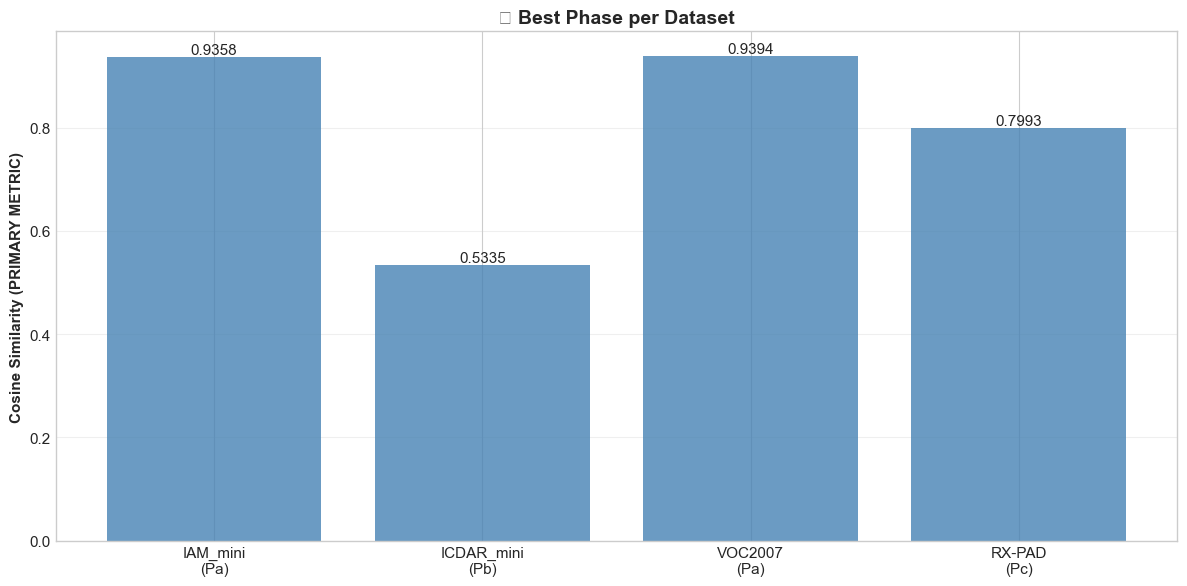

In [ ]:
# Visualize best phase per dataset
fig, ax = plt.subplots(figsize=(12, 6))

# Bar chart
x = range(len(best_phases_df))
bars = ax.bar(x, best_phases_df['Cosine Similarity'], color='steelblue', alpha=0.8)

# Highlight bars
ax.set_xticks(x)
ax.set_xticklabels([f"{row['Dataset']}\n({row['Best Phase']})" 
                     for _, row in best_phases_df.iterrows()])
ax.set_ylabel('Cosine Similarity (PRIMARY METRIC)', fontweight='bold')
ax.set_title('🏆 Best Phase per Dataset', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


## 🎯 Section 4: Best Model per Phase per Dataset

**KEY QUESTION #2: Which is the best model per phase for each dataset?**

This section identifies the best-performing model for each dataset-phase combination.


In [ ]:
# Identify best model per phase per dataset
print("="*80)
print("BEST MODEL PER PHASE PER DATASET")
print("="*80)

best_models_per_phase = []

for dataset in metrics_df['dataset'].unique():
    print(f"\n{dataset}:")
    dataset_data = metrics_df[metrics_df['dataset'] == dataset]
    
    for phase in dataset_data['phase'].unique():
        phase_data = dataset_data[dataset_data['phase'] == phase]
        best_idx = phase_data['cosine_similarity'].idxmax()
        best = phase_data.loc[best_idx]
        
        best_models_per_phase.append({
            'Dataset': dataset,
            'Phase': phase,
            'Best Model': best['model'],
            'Cosine Similarity': best['cosine_similarity'],
            'CER': best['cer'],
            'WER': best['wer']
        })
        
        print(f"  {phase}: {best['model']} (Cosine={best['cosine_similarity']:.4f})")

best_models_df = pd.DataFrame(best_models_per_phase)
print("\n" + "="*80)
print("SUMMARY TABLE:")
display(best_models_df)


BEST MODEL PER PHASE PER DATASET

IAM_mini:
  Pa: azure_intelligence (Cosine=0.9457)
  Pb: claude_sonnet (Cosine=0.9046)
  Pc: gpt-5-mini (Cosine=0.9136)

ICDAR_mini:
  Pa: azure_intelligence (Cosine=0.4668)
  Pb: gpt-5-mini (Cosine=0.5335)
  Pc: gpt-5-mini (Cosine=0.4574)

VOC2007:
  Pa: azure_intelligence (Cosine=0.9394)
  Pb: claude_sonnet (Cosine=0.9394)
  Pc: claude_sonnet (Cosine=0.9394)
  Pd: claude_sonnet (Cosine=0.9394)

RX-PAD:
  Pa: azure_intelligence (Cosine=0.7986)
  Pb: claude_sonnet (Cosine=0.7937)
  Pc: claude_sonnet (Cosine=0.7993)

SUMMARY TABLE:


,Dataset,Phase,Best Model,Cosine Similarity,CER,WER
0,IAM_mini,Pa,azure_intelligence,0.945692,0.089357,0.301115
1,IAM_mini,Pb,claude_sonnet,0.904628,0.162604,0.223442
2,IAM_mini,Pc,gpt-5-mini,0.913616,0.080031,0.109847
3,ICDAR_mini,Pa,azure_intelligence,0.466765,5.394261,4.359991
4,ICDAR_mini,Pb,gpt-5-mini,0.533486,1.943973,1.860400
5,ICDAR_mini,Pc,gpt-5-mini,0.457439,0.740696,0.851191
6,VOC2007,Pa,azure_intelligence,0.939420,0.673055,0.791620
7,VOC2007,Pb,claude_sonnet,0.939420,0.673055,0.791620
8,VOC2007,Pc,claude_sonnet,0.939420,0.673055,0.791620
9,VOC2007,Pd,claude_sonnet,0.939420,0.673055,0.791620


## 🎯 Section 5: Best Combination per Dataset

**KEY QUESTION #3: What's the best combination (phase + model) for each dataset?**

This section identifies the single best phase-model combination for each dataset.


In [ ]:
# Find best combination per dataset
print("="*80)
print("BEST COMBINATION (Phase + Model) PER DATASET")
print("="*80)

best_combinations = []

for dataset in metrics_df['dataset'].unique():
    dataset_data = metrics_df[metrics_df['dataset'] == dataset]
    best_idx = dataset_data['cosine_similarity'].idxmax()
    best = dataset_data.loc[best_idx]
    
    # Get baseline (Pa phase) for comparison
    baseline_data = dataset_data[dataset_data['phase'] == 'Pa']
    if len(baseline_data) > 0:
        baseline_cosine = baseline_data['cosine_similarity'].mean()
        improvement = ((best['cosine_similarity'] - baseline_cosine) / baseline_cosine * 100) if baseline_cosine > 0 else 0
    else:
        improvement = 0
    
    best_combinations.append({
        'Dataset': dataset,
        'Best Phase': best['phase'],
        'Best Model': best['model'],
        'Cosine Similarity': best['cosine_similarity'],
        'CER': best['cer'],
        'WER': best['wer'],
        'Improvement vs Baseline (%)': round(improvement, 2)
    })
    
    print(f"\n{dataset}:")
    print(f"  🏆 Best Combination: {best['phase']} + {best['model']}")
    print(f"  🎯 Cosine Similarity: {best['cosine_similarity']:.4f}")
    print(f"     CER: {best['cer']:.4f}, WER: {best['wer']:.4f}")
    if improvement != 0:
        print(f"     📈 Improvement vs baseline: {improvement:.2f}%")

best_combinations_df = pd.DataFrame(best_combinations)
print("\n" + "="*80)
print("SUMMARY TABLE:")
display(best_combinations_df)


BEST COMBINATION (Phase + Model) PER DATASET

IAM_mini:
  🏆 Best Combination: Pa + azure_intelligence
  🎯 Cosine Similarity: 0.9457
     CER: 0.0894, WER: 0.3011
     📈 Improvement vs baseline: 1.05%

ICDAR_mini:
  🏆 Best Combination: Pb + gpt-5-mini
  🎯 Cosine Similarity: 0.5335
     CER: 1.9440, WER: 1.8604
     📈 Improvement vs baseline: 14.29%

VOC2007:
  🏆 Best Combination: Pa + azure_intelligence
  🎯 Cosine Similarity: 0.9394
     CER: 0.6731, WER: 0.7916

RX-PAD:
  🏆 Best Combination: Pc + claude_sonnet
  🎯 Cosine Similarity: 0.7993
     CER: 0.6591, WER: 0.5828
     📈 Improvement vs baseline: 0.09%

SUMMARY TABLE:


,Dataset,Best Phase,Best Model,Cosine Similarity,CER,WER,Improvement vs Baseline (%)
0,IAM_mini,Pa,azure_intelligence,0.945692,0.089357,0.301115,1.05
1,ICDAR_mini,Pb,gpt-5-mini,0.533486,1.943973,1.860400,14.29
2,VOC2007,Pa,azure_intelligence,0.939420,0.673055,0.791620,0.00
3,RX-PAD,Pc,claude_sonnet,0.799310,0.659092,0.582753,0.09


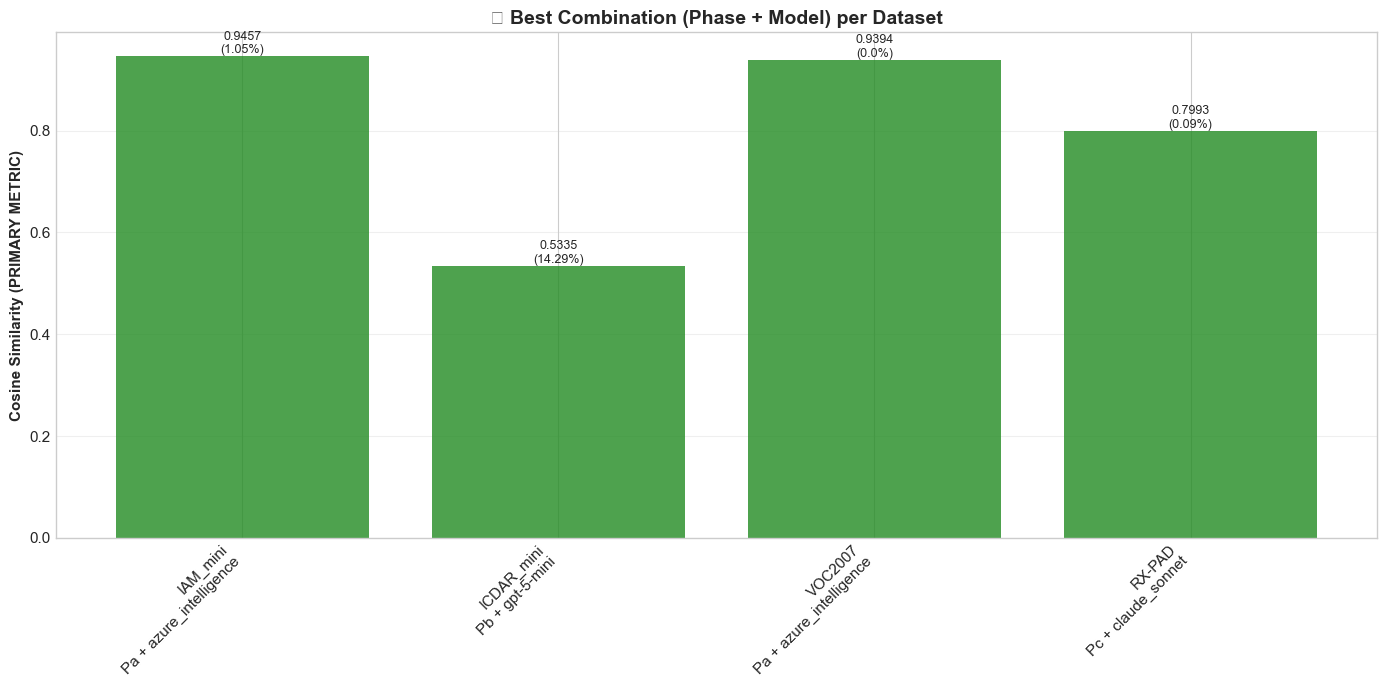

In [ ]:
# Visualize best combinations
fig, ax = plt.subplots(figsize=(14, 7))

x = range(len(best_combinations_df))
bars = ax.bar(x, best_combinations_df['Cosine Similarity'], 
              color='forestgreen', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels([f"{row['Dataset']}\n{row['Best Phase']} + {row['Best Model']}" 
                     for _, row in best_combinations_df.iterrows()], 
                    rotation=45, ha='right')
ax.set_ylabel('Cosine Similarity (PRIMARY METRIC)', fontweight='bold')
ax.set_title('🏆 Best Combination (Phase + Model) per Dataset', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}\n({best_combinations_df.iloc[i]["Improvement vs Baseline (%)"]}%)',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
# Export summary tables
output_dir = RESULTS_BASE / '4_notebooks' / 'output'
output_dir.mkdir(exist_ok=True)

best_phases_df.to_csv(output_dir / 'best_phases_parsing.csv', index=False)
best_models_df.to_csv(output_dir / 'best_models_per_phase_parsing.csv', index=False)
best_combinations_df.to_csv(output_dir / 'best_combinations_parsing.csv', index=False)

print("✅ Summary tables exported:")
print(f"   - {output_dir / 'best_phases_parsing.csv'}")
print(f"   - {output_dir / 'best_models_per_phase_parsing.csv'}")
print(f"   - {output_dir / 'best_combinations_parsing.csv'}")


✅ Summary tables exported:
   - /Users/kenzabenkirane/Documents/GitHub/research-playground/ocr_vs_vlm/results/4_notebooks/output/best_phases_parsing.csv
   - /Users/kenzabenkirane/Documents/GitHub/research-playground/ocr_vs_vlm/results/4_notebooks/output/best_models_per_phase_parsing.csv
   - /Users/kenzabenkirane/Documents/GitHub/research-playground/ocr_vs_vlm/results/4_notebooks/output/best_combinations_parsing.csv


## 📊 Final Summary

This notebook has answered the 3 key questions:

### ✅ Question 1: Best Phase per Dataset
Identified the optimal phase for each dataset based on Cosine Similarity (PRIMARY metric).

### ✅ Question 2: Best Model per Phase per Dataset
Identified the best-performing model for each dataset-phase combination.

### ✅ Question 3: Best Combination per Dataset
Identified the single best phase-model combination per dataset with improvement percentages.

**Exported Files:**
- `best_phases_parsing.csv` - Best phase per dataset
- `best_models_per_phase_parsing.csv` - Best model for each dataset-phase
- `best_combinations_parsing.csv` - Best phase-model per dataset

**Next Steps:**
- Review [qa_analysis.ipynb](qa_analysis.ipynb) for QA task analysis
- Use results for production model selection
- Refer to individual dataset notebooks in `by_dataset/` for detailed analysis
